# Práctica Final TI24 - Análisis Exploratorio de Datos (EDA)
## Tema: Bagging - Random Forests
### Dataset: Loan Default Prediction


### Objetivo de este notebook

En este notebook se realiza el **Análisis Exploratorio de Datos (EDA)** del dataset
de predicción de incumplimiento de préstamos (*Loan Default*). El objetivo es
entender la estructura de los datos, identificar valores nulos, analizar la
distribución de las variables y detectar relaciones con la variable objetivo
`Default`, antes de pasar a la etapa de preprocesamiento y modelado con
Random Forests.


## 1. Importación de librerías

Se importan las librerías necesarias para manipulación de datos (`pandas`, `numpy`)
y visualización (`matplotlib`, `seaborn`).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)


## 2. Carga del dataset

El dataset se carga directamente desde el repositorio de GitHub del proyecto,
desde la carpeta `data/raw/`. Esto asegura que el notebook sea reproducible
sin depender de archivos locales.


In [ ]:
url = "https://raw.githubusercontent.com/soledadaldunate/repositorio-TI24-Aldunate/main/data/raw/Loan_default.csv"
df = pd.read_csv(url)
df.head()


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 3. Información general del dataset

Se revisa la cantidad de filas y columnas, los tipos de datos de cada variable
y un resumen general de la estructura del dataset.


In [ ]:
print("Cantidad de filas y columnas:", df.shape)
print("\nTipos de datos por columna:")
df.info()


Cantidad de filas y columnas: (255347, 18)

Tipos de datos por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-nul

**Interpretación:** Esta información nos permite confirmar que el dataset
cumple con el mínimo de 5000 filas y 13 columnas requerido, y nos da una
primera idea de cuáles variables son numéricas y cuáles son categóricas
(tipo `object`).


## 4. Análisis de valores nulos

Se calcula la cantidad y el porcentaje de valores nulos por columna. Esto es
fundamental para decidir qué estrategia de imputación usar en la etapa de
preprocesamiento.


In [ ]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    "Valores nulos": nulos,
    "Porcentaje (%)": porcentaje.round(2)
})

resumen_nulos.sort_values("Valores nulos", ascending=False)


,Valores nulos,Porcentaje (%)
LoanID,0,0.0
Age,0,0.0
Income,0,0.0
LoanAmount,0,0.0
CreditScore,0,0.0
MonthsEmployed,0,0.0
NumCreditLines,0,0.0
InterestRate,0,0.0
LoanTerm,0,0.0
DTIRatio,0,0.0


**Interpretación:** Si existen columnas con valores nulos, se deberá
decidir si se imputan (con media, mediana o moda) o si se eliminan las filas,
dependiendo del porcentaje de datos faltantes.


## 5. Estadísticas descriptivas de variables numéricas

Se obtienen medidas como media, desviación estándar, mínimo, máximo y
percentiles, para entender la escala y dispersión de cada variable numérica.


In [ ]:
variables_numericas = ["Age", "Income", "LoanAmount", "CreditScore",
                       "MonthsEmployed", "NumCreditLines", "InterestRate",
                       "LoanTerm", "DTIRatio"]

df[variables_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9


**Interpretación:** Variables como `Income` y `LoanAmount` probablemente
tengan escalas muy distintas (miles vs decenas), lo que confirma que será
necesario aplicar **escalado (scaling)** en el preprocesamiento.


## 6. Distribución de la variable objetivo (`Default`)

`Default` es la variable que queremos predecir: indica si la persona
incumplió (1) o no (0) el pago del préstamo. Es importante revisar si las
clases están balanceadas, ya que esto afecta cómo se entrena y evalúa el
modelo de Random Forest.


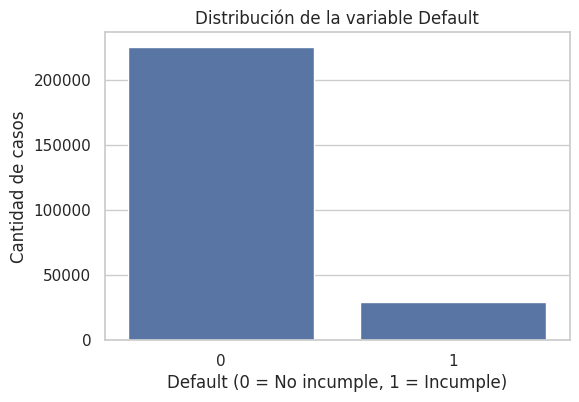

Distribución porcentual:
Default
0    88.4
1    11.6
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Default")
plt.title("Distribución de la variable Default")
plt.xlabel("Default (0 = No incumple, 1 = Incumple)")
plt.ylabel("Cantidad de casos")
plt.show()

print("Distribución porcentual:")
print(df["Default"].value_counts(normalize=True).round(3) * 100)


**Interpretación:** Si la clase 1 (incumplimiento) representa un
porcentaje bajo del total, estamos ante un problema de **clases
desbalanceadas**. Esto se debe tener en cuenta al elegir métricas de
evaluación (F1-score y matriz de confusión, además de accuracy).


## 7. Distribución de las variables numéricas

Se grafican histogramas para observar la forma de la distribución (normal,
sesgada, con outliers, etc.) de cada variable numérica.


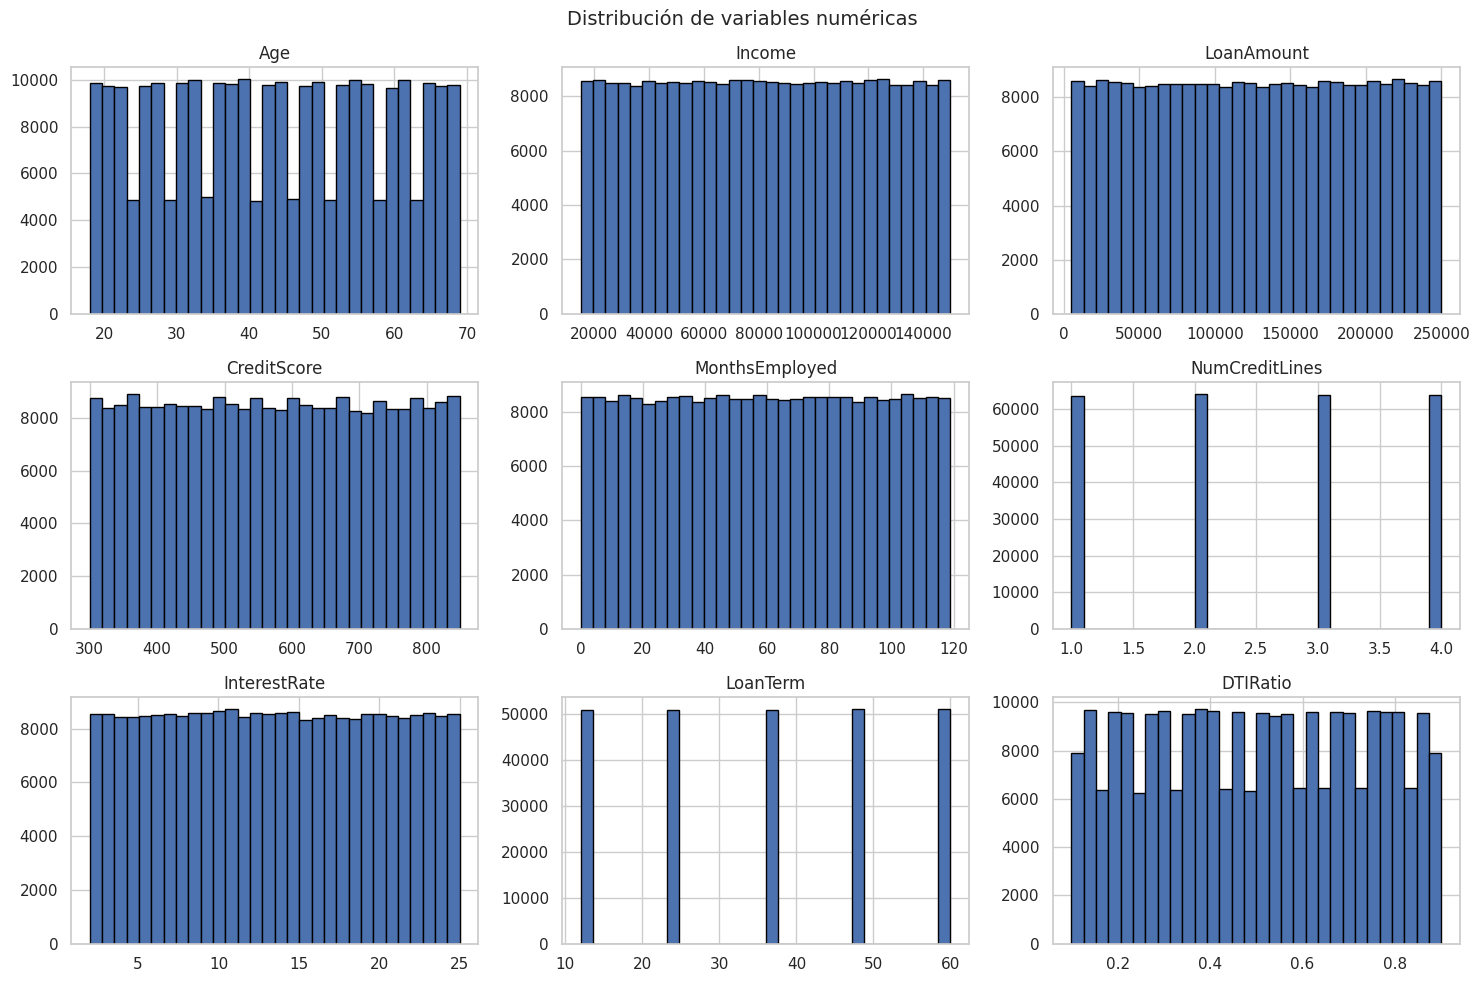

In [ ]:
df[variables_numericas].hist(bins=30, figsize=(15,10), edgecolor="black")
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()


**Interpretación:** Variables muy sesgadas (asimétricas) podrían
beneficiarse de transformaciones logarítmicas, aunque Random Forest es
robusto a este tipo de distribuciones, a diferencia de modelos lineales.


## 8. Detección de outliers (valores atípicos)

Los boxplots permiten identificar valores extremos que podrían afectar el
análisis o requerir tratamiento especial en el preprocesamiento.


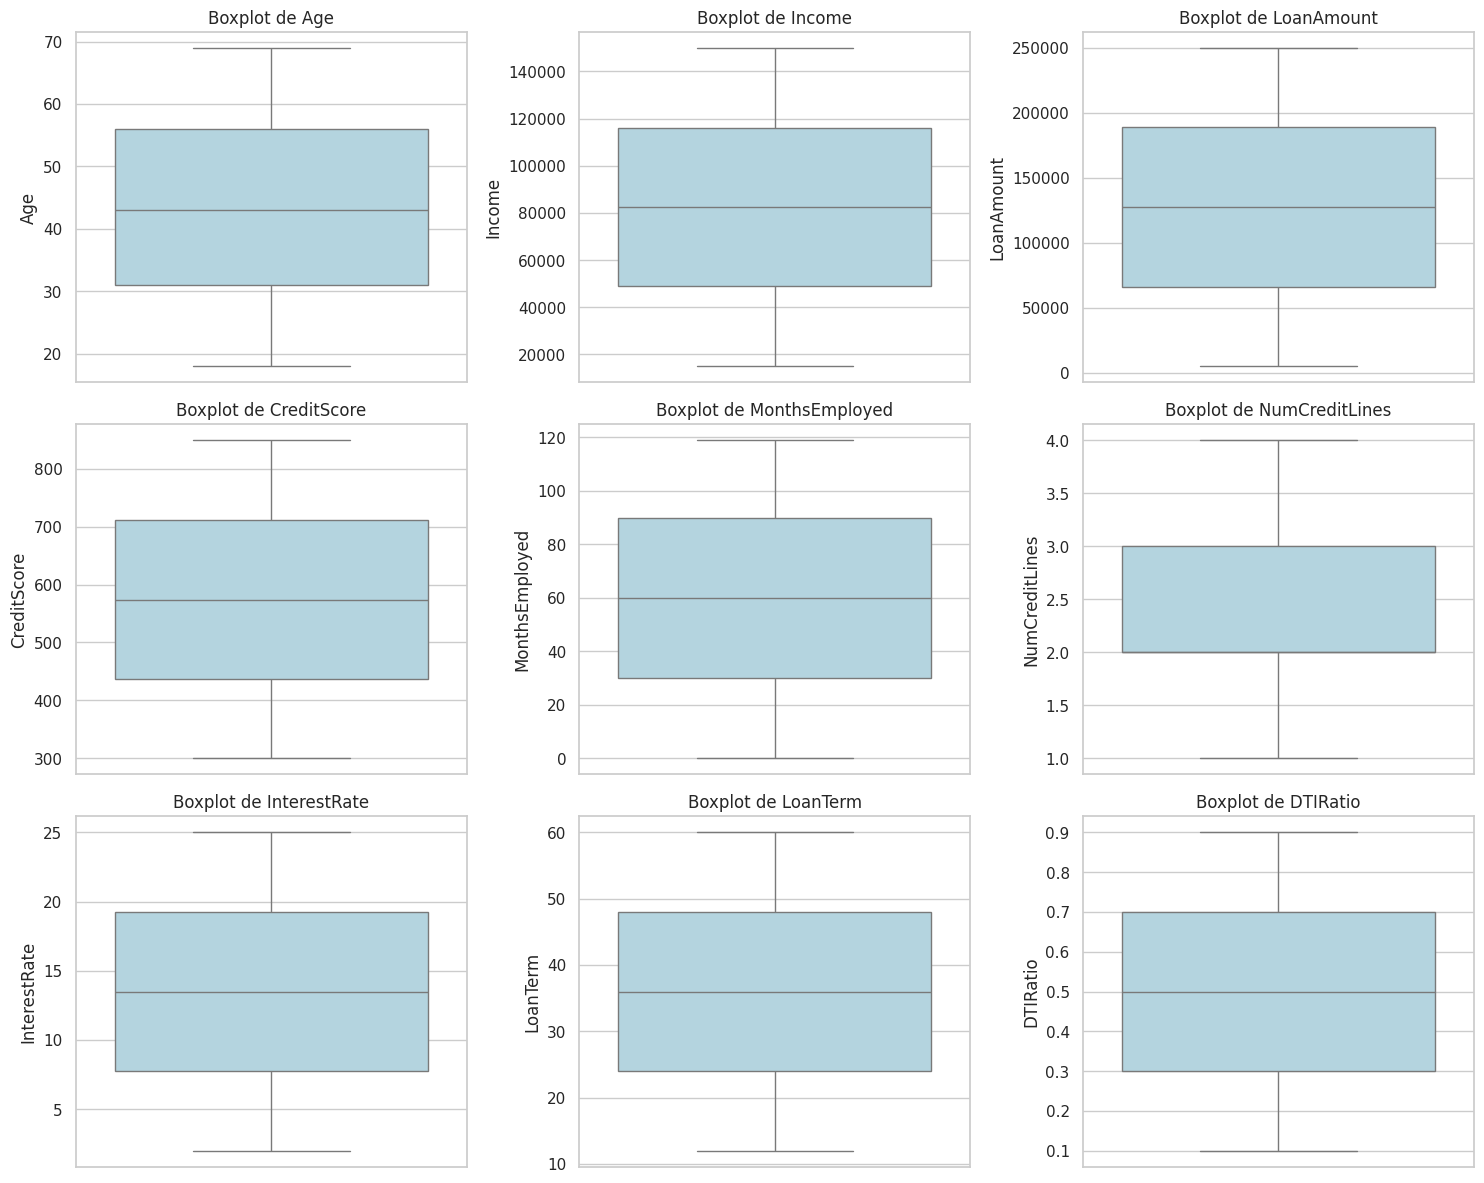

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(data=df, y=col, ax=axes[i], color="lightblue")
    axes[i].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()


**Interpretación:** Los puntos que aparecen fuera de los "bigotes" del
boxplot son valores atípicos. Se debe decidir si se conservan (porque pueden
ser información real, por ejemplo ingresos altos legítimos) o si se tratan
de errores de captura de datos.


## 9. Distribución de variables categóricas

Se analiza cuántas categorías tiene cada variable categórica y cómo se
distribuyen los datos entre ellas.


In [ ]:
variables_categoricas = ["Education", "EmploymentType", "MaritalStatus",
                         "HasMortgage", "HasDependents", "LoanPurpose",
                         "HasCoSigner"]

for col in variables_categoricas:
    print(f"\nVariable: {col}")
    print(df[col].value_counts())
    print("-"*40)



Variable: Education
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64
----------------------------------------

Variable: EmploymentType
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64
----------------------------------------

Variable: MaritalStatus
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64
----------------------------------------

Variable: HasMortgage
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64
----------------------------------------

Variable: HasDependents
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64
----------------------------------------

Variable: LoanPurpose
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64
--------------------------------------

/tmp/ipykernel_3411/922539799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="pastel")
/tmp/ipykernel_3411/922539799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="pastel")
/tmp/ipykernel_3411/922539799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="pastel")
/tmp/ipykernel_3411/922539799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

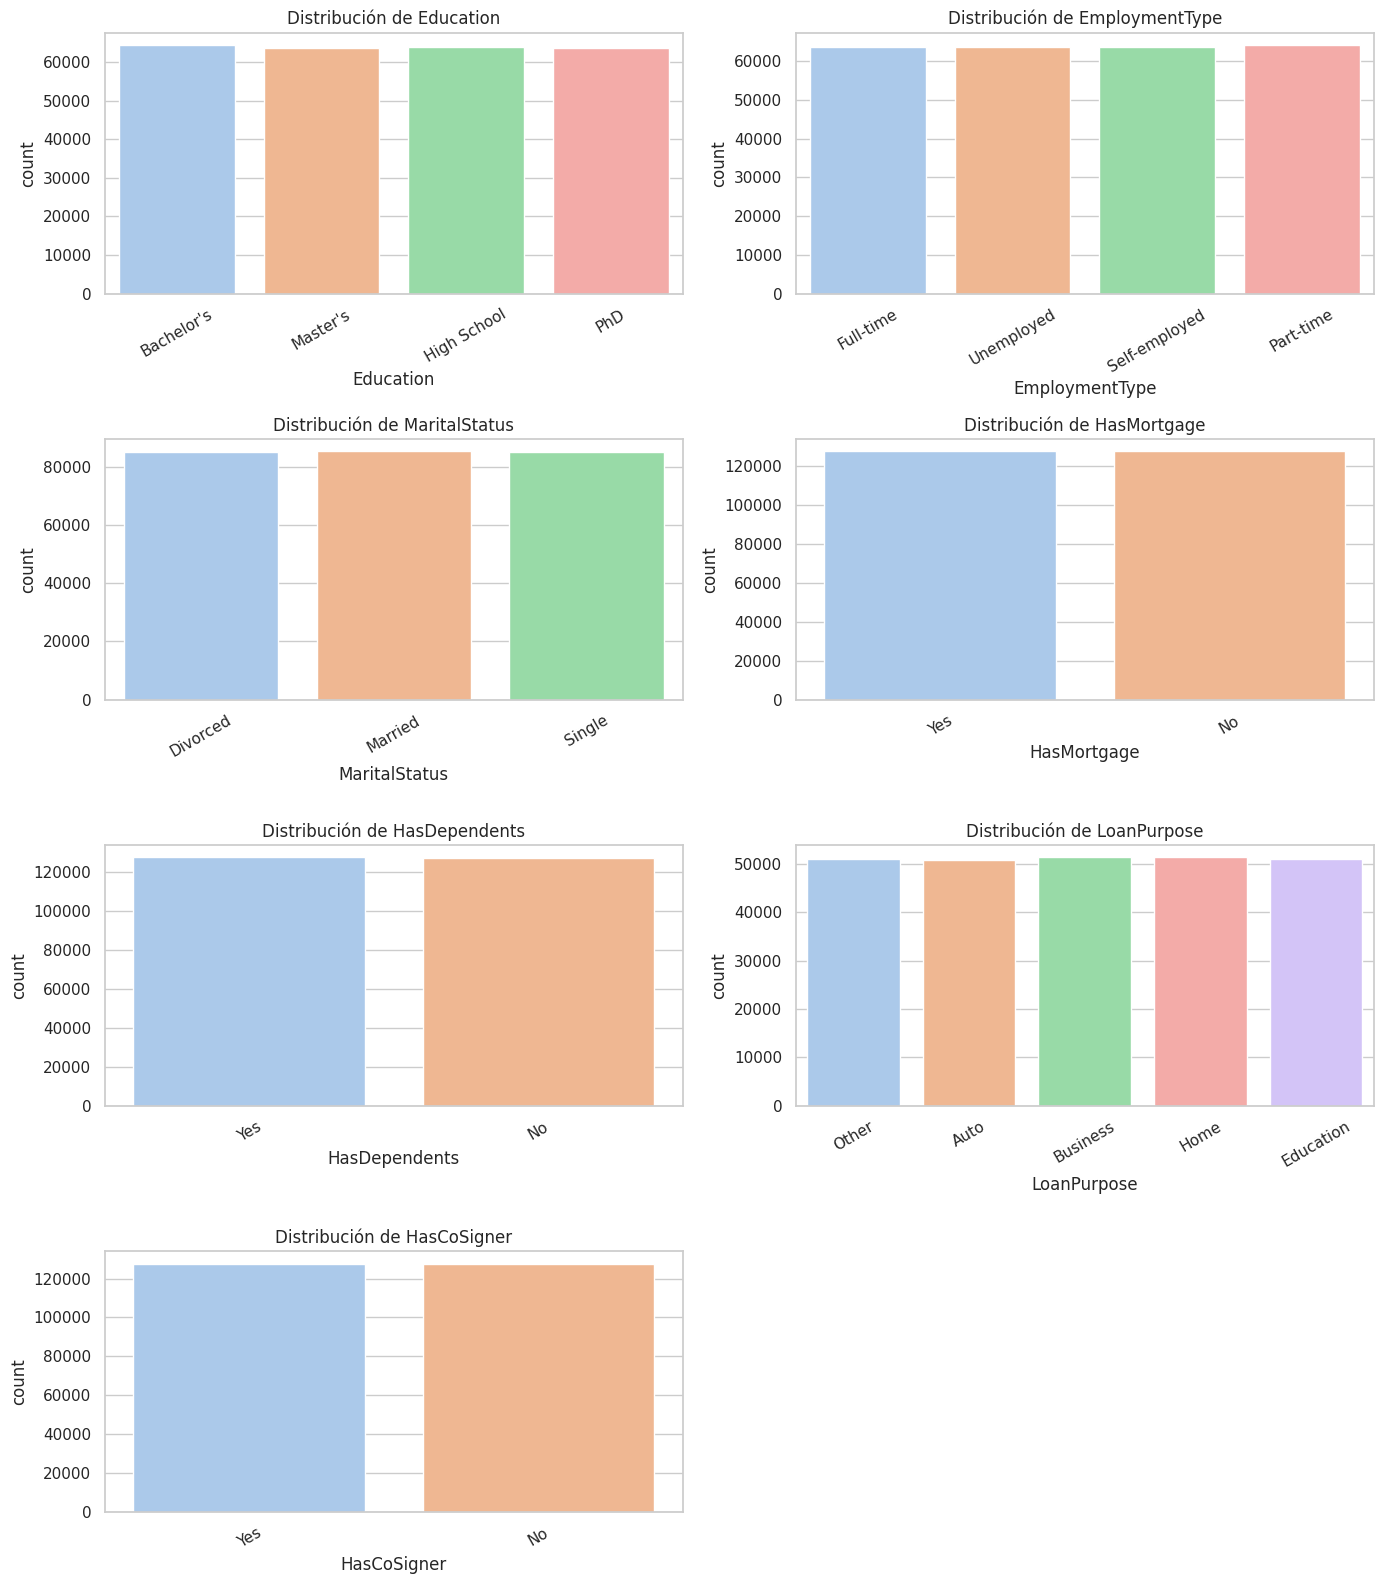

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    sns.countplot(data=df, x=col, ax=axes[i], palette="pastel")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 10. Relación entre variables categóricas y la variable objetivo

Se analiza si existe alguna relación visible entre las categorías y la
probabilidad de incumplimiento (`Default`).


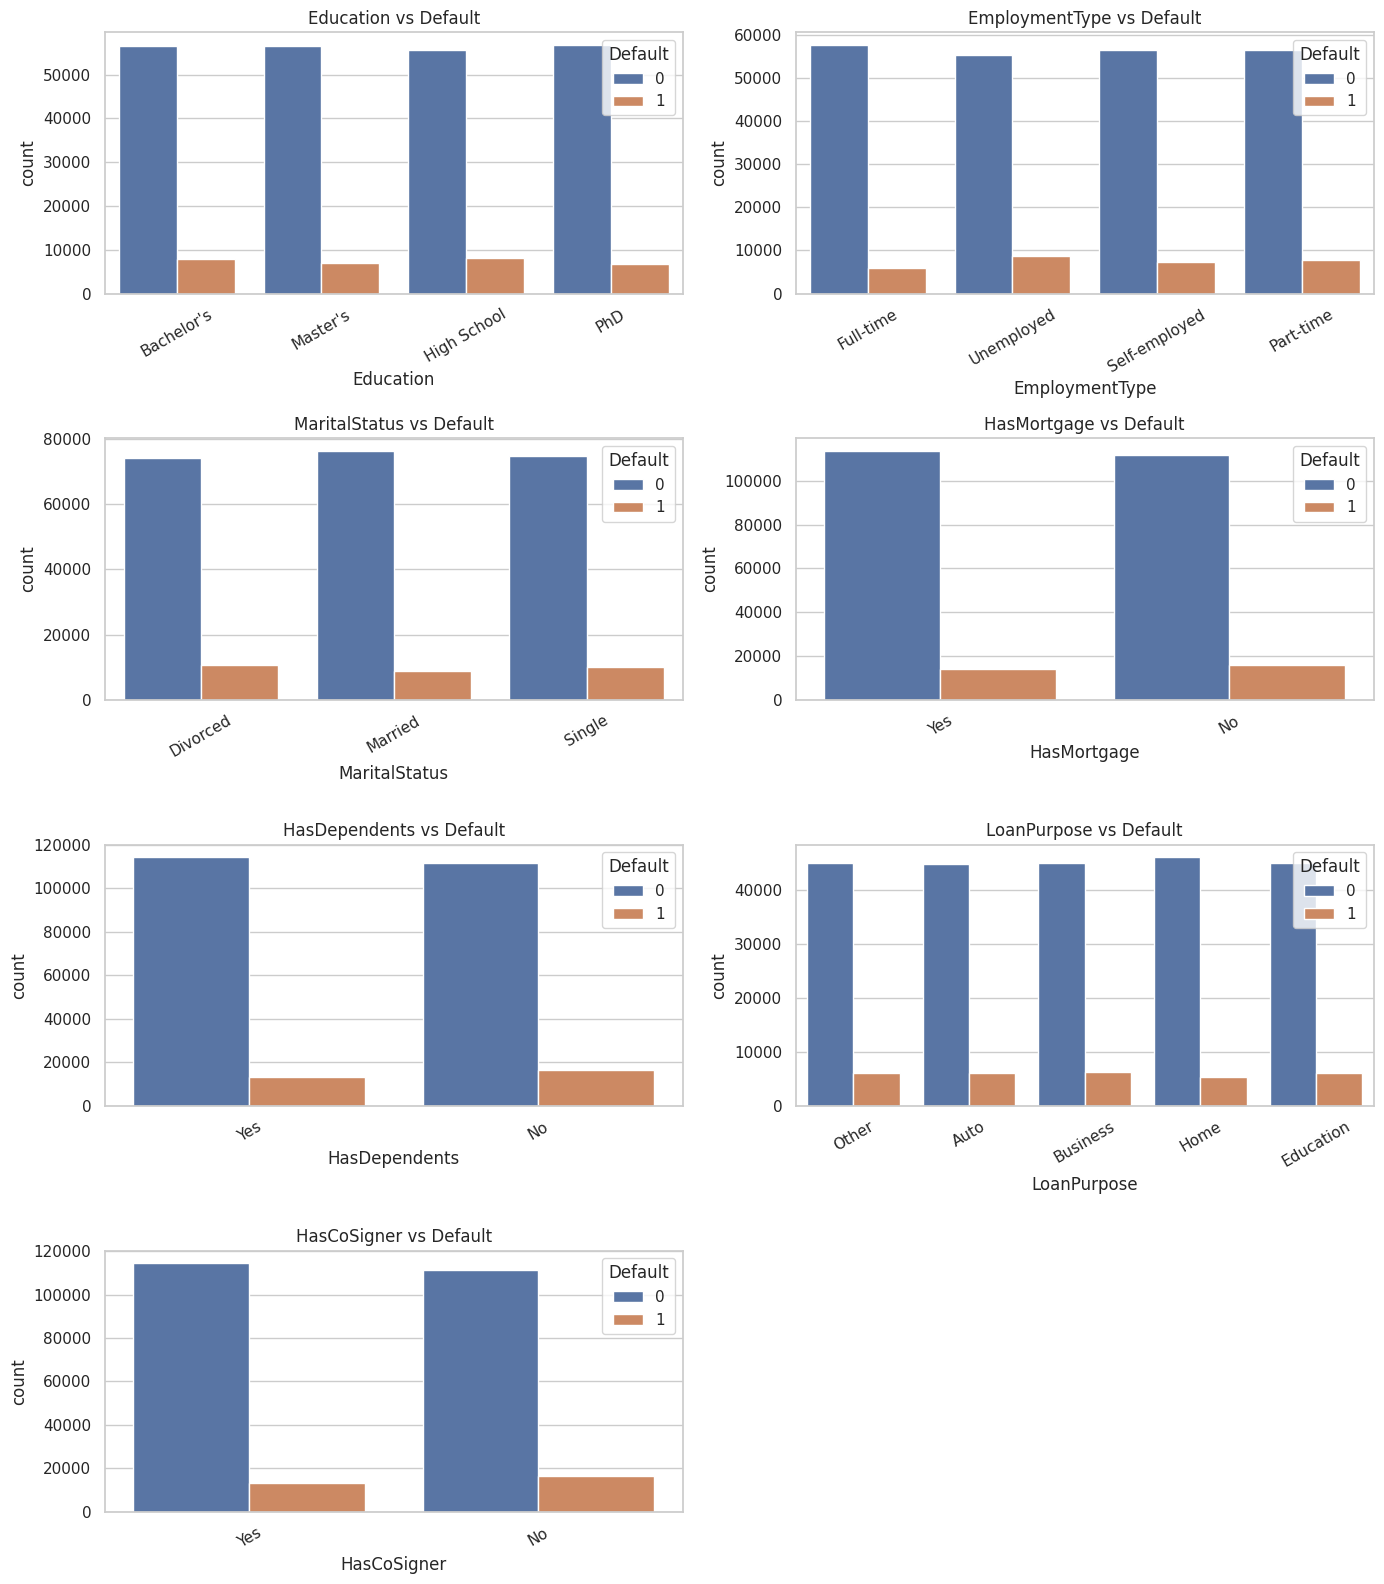

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    sns.countplot(data=df, x=col, hue="Default", ax=axes[i])
    axes[i].set_title(f"{col} vs Default")
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 11. Matriz de correlación entre variables numéricas

Se calcula la correlación de Pearson entre las variables numéricas y la
variable objetivo, para identificar relaciones lineales.


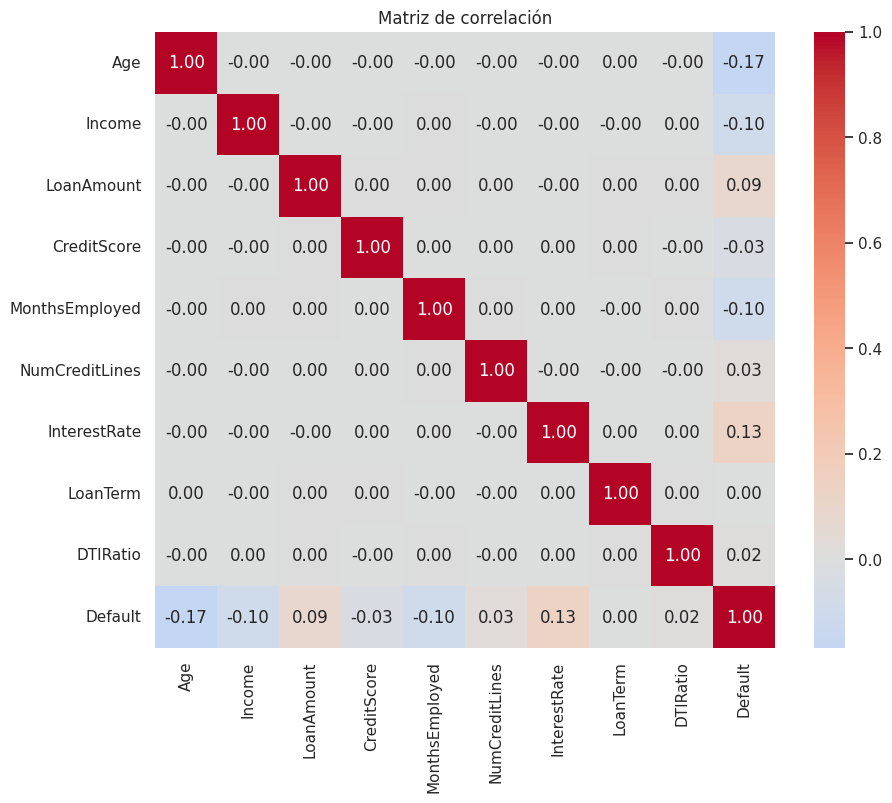

In [ ]:
plt.figure(figsize=(10,8))
correlaciones = df[variables_numericas + ["Default"]].corr()
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()
